[[-6.13427678e-11  4.25539918e-11 -6.88394336e-12]
 [ 2.97779703e-11  2.98498393e-11  1.00000000e+00]
 [ 5.45519455e-12  1.00000000e+00 -7.54094614e-11]
 [ 2.00000000e+00  1.00000000e+00  1.00000000e+00]
 [ 2.00000000e+00 -1.37371906e-11  1.00000000e+00]
 [-1.93949468e-11  1.00000000e+00  1.00000000e+00]]


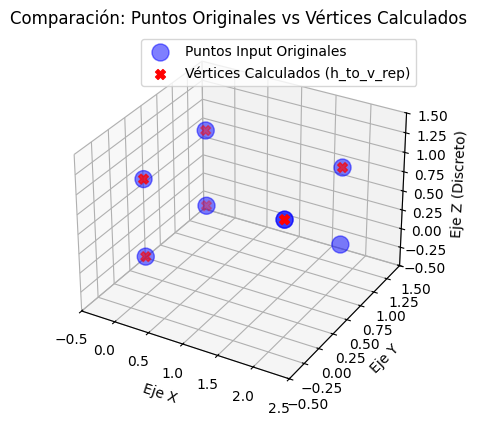

In [36]:
from get_cpoints import h_to_v_rep
from convex_hull import generate_convex_hull
import matplotlib.pyplot as plt
import numpy as np

verts_originales = np.array([(0,0,0), (0,1,0), (0,0,1), (0,1,1),
                             (2,0,1), (2,1,0), (2,0,1), (2,1,1)])

A, b = generate_convex_hull(verts_originales)

vertices_calculados = h_to_v_rep(A, b)
print(vertices_calculados)

#plotear los vértices
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(verts_originales[:, 0], verts_originales[:, 1], verts_originales[:, 2], 
           c='blue', s=150, label='Puntos Input Originales', alpha=0.5)

ax.scatter(vertices_calculados[:, 0], vertices_calculados[:, 1], vertices_calculados[:, 2], 
           c='red', s=50, label='Vértices Calculados (h_to_v_rep)', marker='X')

# Etiquetas y leyenda
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Eje Z (Discreto)')
ax.set_title('Comparación: Puntos Originales vs Vértices Calculados')
ax.legend()

# Ajustar límites para ver mejor
all_pts = np.vstack((verts_originales, vertices_calculados))
ax.set_xlim(all_pts[:,0].min()-0.5, all_pts[:,0].max()+0.5)
ax.set_ylim(all_pts[:,1].min()-0.5, all_pts[:,1].max()+0.5)
ax.set_zlim(all_pts[:,2].min()-0.5, all_pts[:,2].max()+0.5)

plt.show()

In [37]:
# Crear un diccionario vacío
mi_diccionario = {}

# Agregar una nueva llave y su valor
mi_diccionario["nombre"] = "Ana"
mi_diccionario["edad"] = 28

print(mi_diccionario)
# Salida: {'nombre': 'Ana', 'edad': 28}

mi_diccionario.update({"ciudad": "Madrid", "profesion": "Ingeniera"})
print(mi_diccionario)



{'nombre': 'Ana', 'edad': 28}
{'nombre': 'Ana', 'edad': 28, 'ciudad': 'Madrid', 'profesion': 'Ingeniera'}


In [38]:
import numpy as np
vertices = np.asarray([(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1),
            (2, 0, 0), (2, 0, 1), (2, 1, 0), (2, 1, 1)])
vertices = vertices[:, 1:]
punto_interior = np.asarray(np.mean(vertices, axis = 0))

print(punto_interior)


[0.5 0.5]


In [39]:
import numpy as np

def ordenar_vertices(vertices_slice):
    """
    ordenar los vértices (de cada slice) para poder ocupar la fórmula en la sgte función
    input:
        vertices_slice : vértices por correspondientes a cada slice
    """
    # Trabajamos como array
    vertices_slice = np.asarray(vertices_slice)
    # Primero me quedo con las coordenadas (x,y)
    vertices = vertices_slice[:, 1:]

    # Elegir un centro
    # Podría ser el centro de Chebyshev, pero necesito su H representation para eso
    # Así que por mientra trabajo con el promedio de los puntos
    # Que es un punto interior por lo menos
    centro = np.asarray(np.mean(vertices, axis = 0))


    # Sacarle vector a los vértices desde el centro hasta cada uno
    vectores = []
    for i in vertices:
        u_i = i - centro
        vectores.append(u_i)

    # Ahora calcular el ángulo respecto al centro con cada uno de los vectores
    # El primero vector en de referencia
    u_ref = vectores[0]

    # Como arccos me entrega valores entre [0,pi], voy a ordenarlos por los puntos a su izquierda
    # y los puntos a su derecha, de menor a mayor ángulo
    # Luego los puedo juntar en una lista
    puntos_izq = {tuple(u_ref) : 0}
    puntos_der = {}
    
    vectores_a_ordenar = vectores[1:] # Sublista con los que hay que ordenar
    for i in vectores_a_ordenar:
        # Siguiendo la fórmula theta_i = arccos( <u_ref, u_i> / (||u_ref|| ||u_i||) )
        theta_i = np.arccos(np.dot(u_ref, i)/(np.linalg.norm(u_ref) * np.linalg.norm(i)))

        #determinar si quedó a la izquiera o la derecha
        det = u_ref[0]*i[1] - u_ref[1]*i[0]
        if det >= 0:
            puntos_izq.update({tuple(i) : theta_i})
        else:
            puntos_der.update({tuple(i) : theta_i})

    # Ahora hay que sortear los diccionarios según ángulo
    puntos_ordenados_izq = dict(sorted(puntos_izq.items(), key = lambda item : item[1]))
    puntos_ordenados_der = dict(sorted(puntos_der.items(), key = lambda item : item[1]))

    # Y juntar las listas
    puntos_ordenados = []

    for i in puntos_ordenados_izq.keys():
        puntos_ordenados.append(i)
    for i in reversed(puntos_ordenados_der.keys()):
        puntos_ordenados.append(i)
       
        
    return puntos_ordenados

slice: 0
[[0.         0.02195699 0.01228805]
 [0.         0.71811756 0.77038369]
 [0.         0.22476737 0.49330748]
 [0.         0.96593157 0.33473682]
 [0.         0.59938242 0.34039335]]
slice: 1
[[1.         0.58586557 0.43520011]
 [1.         0.98419805 0.60537133]
 [1.         0.99982315 0.39398313]
 [1.         0.84159123 0.73518168]
 [1.         0.12702434 0.92244903]]
slice: 2
[[2.         0.01073589 0.10809822]
 [2.         0.29236527 0.9884851 ]
 [2.         0.45057737 0.37448311]
 [2.         0.95399437 0.37232096]
 [2.         0.78913619 0.1515371 ]]


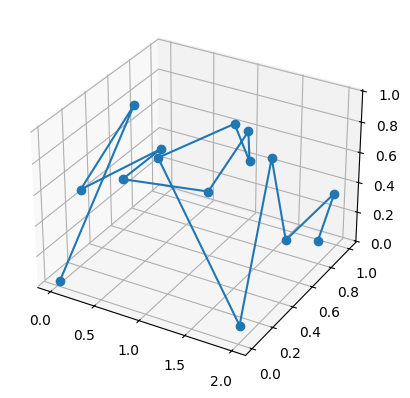

In [40]:
from convex_hull import random_vertices_by_fiber
import matplotlib.pyplot as plt
verts = random_vertices_by_fiber([0,1,2], 2, 5)

for z, i in enumerate(range(0, len(verts), 5)):
    grupo = verts[i:i+5]
    print("slice:", z)
    print(grupo)

z = [v[0] for v in verts]
x = [v[1] for v in verts]
y = [v[2] for v in verts]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

plt.plot(z, x, y, marker="o")
plt.show()


slice: 0
[[0.         0.02195699 0.01228805]
 [0.         0.71811756 0.77038369]
 [0.         0.22476737 0.49330748]
 [0.         0.96593157 0.33473682]
 [0.         0.59938242 0.34039335]]


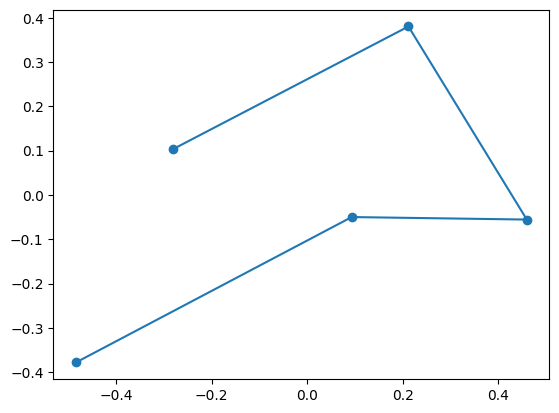

slice: 1
[[1.         0.58586557 0.43520011]
 [1.         0.98419805 0.60537133]
 [1.         0.99982315 0.39398313]
 [1.         0.84159123 0.73518168]
 [1.         0.12702434 0.92244903]]


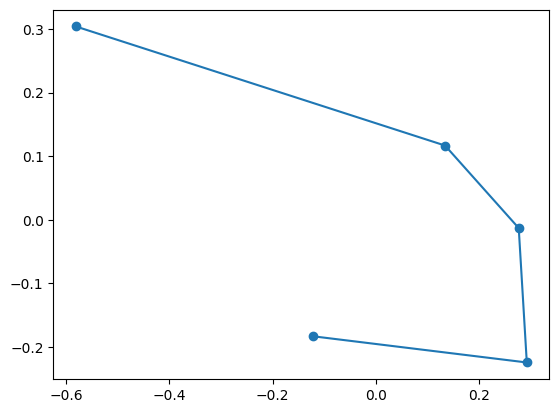

slice: 2
[[2.         0.01073589 0.10809822]
 [2.         0.29236527 0.9884851 ]
 [2.         0.45057737 0.37448311]
 [2.         0.95399437 0.37232096]
 [2.         0.78913619 0.1515371 ]]


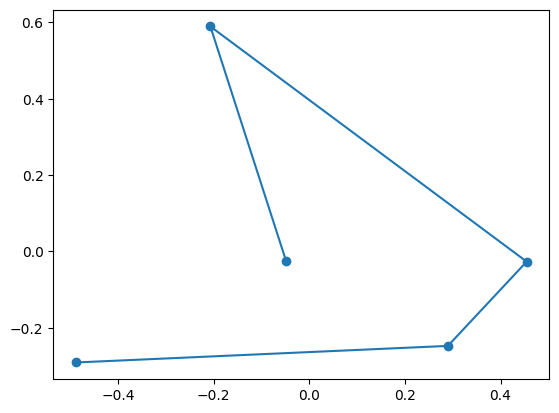

[array([ 0.        , -0.48407419, -0.37793383]), array([ 0.        ,  0.09335124, -0.04982853]), array([ 0.        ,  0.45990038, -0.05548506]), array([0.        , 0.21208638, 0.38016181]), array([ 0.        , -0.28126381,  0.1030856 ]), array([ 1.        , -0.1218349 , -0.18323695]), array([ 1.        ,  0.29212268, -0.22445392]), array([ 1.        ,  0.27649758, -0.01306573]), array([1.        , 0.13389076, 0.11674462]), array([ 1.        , -0.58067613,  0.30401198]), array([ 2.        , -0.48862592, -0.29088668]), array([ 2.        ,  0.28977437, -0.2474478 ]), array([ 2.        ,  0.45463256, -0.02666393]), array([ 2.        , -0.20699655,  0.5895002 ]), array([ 2.        , -0.04878445, -0.02450179])]


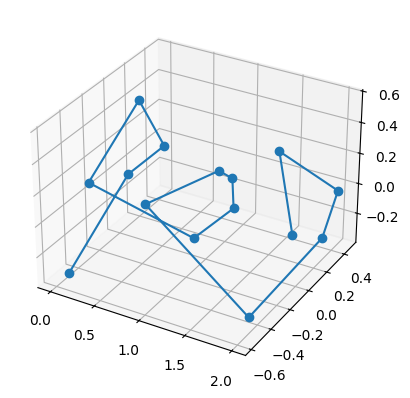

In [41]:
orden_final = []
for z, i in enumerate(range(0, len(verts), 5)):
    grupo = verts[i:i+5]
    print("slice:", z)
    print(grupo)

    vertices_ordenados = ordenar_vertices(grupo)

    x = [v[0] for v in vertices_ordenados]
    y = [v[1] for v in vertices_ordenados]

    plt.plot(x, y, marker="o")
    plt.show()

    z_col = np.full((len(vertices_ordenados), 1), z)
    vertices_3d = np.hstack((z_col, vertices_ordenados))
    orden_final.extend(vertices_3d)

print(orden_final)

z = [v[0] for v in orden_final]
x = [v[1] for v in orden_final]
y = [v[2] for v in orden_final]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

plt.plot(z, x, y, marker="o")
plt.show()
